# Python Notebook 1: Data Understanding and Preprocessing
## 5DATA002W.2 – Machine Learning & Data Mining
**Author:** Viraj Jayasiri - w2153009  
**Code Peer Reviewer:** Maneth Liyanage  
**Peer Review Date:** 11/02/2026  
**Module:** 5DATA002W.2 – Machine Learning & Data Mining  

---
This notebook contains all data understanding and preparation tasks for the Loan Approval dataset.
It produces two cleaned datasets:
- **Dataset A (Classification):** All records for predicting Loan Approval Status
- **Dataset B (Regression):** Approved clients only for predicting Maximum Loan Amount

## Code Reuse Session 1 – Task: Import Required Libraries
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical computations
import numpy as np

# Import matplotlib and seaborn for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Import LabelEncoder for encoding categorical features
from sklearn.preprocessing import LabelEncoder

# Import warnings module to suppress non-critical warnings
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for professional-looking plots
sns.set_style('whitegrid')

# Print confirmation of successful imports
print('All libraries imported successfully.')

All libraries imported successfully.


## Code Reuse Session 1 – Task: Load the Dataset
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [2]:
# Load the loan approval dataset from CSV into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/k_ml/loan_approval_data.csv')

# Display the first 5 rows to inspect the raw data
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


## Code Reuse Session 1 – Task: Inspect Dataset Shape, Data Types and Missing Values
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [3]:
# Display the shape (rows, columns) of the raw dataset
print('Dataset Shape:', df.shape)

# Display column names and their data types
print('\nData Types:')
print(df.dtypes)

# Count the number of missing values per column
print('\nMissing Values per Column:')
print(df.isnull().sum())

Dataset Shape: (58645, 13)

Data Types:
id                           int64
age                        float64
income                       int64
home_ownership              object
emplyment_length             int64
loan_intent                 object
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file     object
credit_history_length        int64
loan_approval_status         int64
max_allowed_loan             int64
dtype: object

Missing Values per Column:
id                          0
age                         6
income                      0
home_ownership              0
emplyment_length            0
loan_intent                 0
loan_amount                 0
loan_interest_rate         11
loan_income_ratio           0
payment_default_on_file     5
credit_history_length       0
loan_approval_status        0
max_allowed_loan            0
dtype: int64


## Code Reuse Session 1 – Task: Descriptive Statistics
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [4]:
# Generate descriptive statistics for all numerical columns (count, mean, std, min, max, quartiles)
df.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


In [5]:
# Generate descriptive statistics for categorical columns (count, unique, top, freq)
df.describe(include='object')

,home_ownership,loan_intent,payment_default_on_file
count,58645,58645,58640
unique,4,6,2
top,RENT,EDUCATION,N
freq,30594,12271,49940


## Code Reuse Session 1 – Task: Visualise Target Variable Distribution (Loan Approval Status)
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

**Note:** In this dataset, `loan_approval_status` uses the encoding from the specification's *Credit Application Acceptance* field: **0 = Approved (Yes)**, **1 = Rejected (No)**.

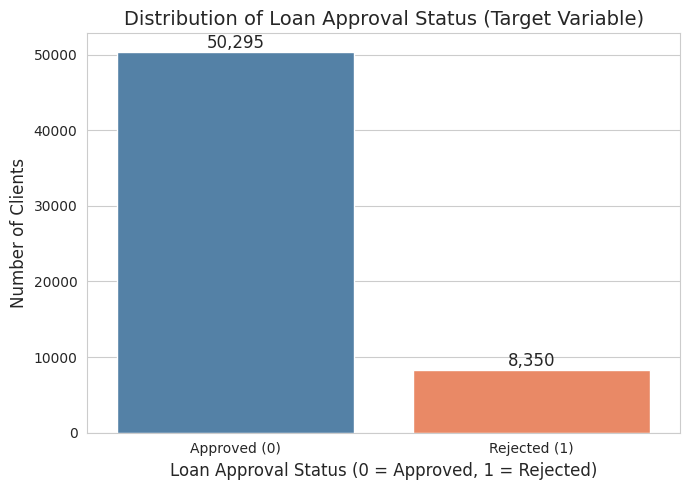

Class Distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

Percentage breakdown:
loan_approval_status
0    85.76
1    14.24
Name: proportion, dtype: float64


In [6]:
# Plot the distribution of the target variable: Loan Approval Status
plt.figure(figsize=(7, 5))

# Count values and create a bar chart with custom labels
counts = df['loan_approval_status'].value_counts()
ax = sns.countplot(x='loan_approval_status', data=df, palette=['steelblue', 'coral'])

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Set axis labels and title
plt.xlabel('Loan Approval Status (0 = Approved, 1 = Rejected)', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.title('Distribution of Loan Approval Status (Target Variable)', fontsize=14)
plt.xticks([0, 1], ['Approved (0)', 'Rejected (1)'])
plt.tight_layout()
plt.show()

# Print class percentages
print('Class Distribution:')
print(df['loan_approval_status'].value_counts())
print('\nPercentage breakdown:')
print(df['loan_approval_status'].value_counts(normalize=True).mul(100).round(2))

## Code Reuse Session 1 – Task: Identify Data Issues – Outliers in Age
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

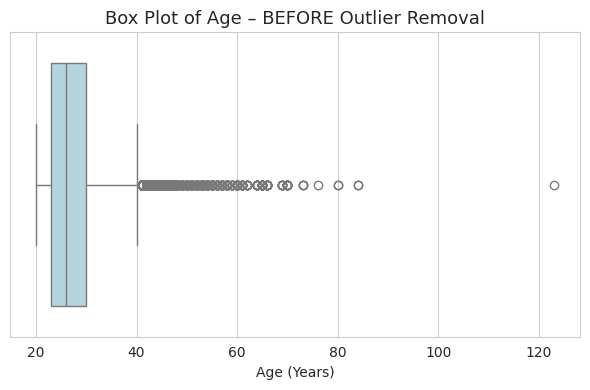

Top 5 highest age values (before fix):
[123.  84.  84.  80.  80.]

Number of records with age > 100: 1


In [7]:
# Box plot to identify outliers in the 'age' column
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['age'], color='lightblue')
plt.title('Box Plot of Age – BEFORE Outlier Removal', fontsize=13)
plt.xlabel('Age (Years)')
plt.tight_layout()
plt.show()

# Print the maximum age values to identify the outlier
print('Top 5 highest age values (before fix):')
print(df['age'].nlargest(5).values)

# Count records where age > 100 (biologically implausible)
print(f'\nNumber of records with age > 100: {(df["age"] > 100).sum()}')

## Code Reuse Session 1 – Task: Identify Data Issues – Negative Values in max_allowed_loan
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [8]:
# Check for negative values in max_allowed_loan (invalid loan amounts)
print('max_allowed_loan – BEFORE fix:')
print(f'Number of negative values: {(df["max_allowed_loan"] < 0).sum()}')

# Display the rows with negative max_allowed_loan values
print('\nRows with negative max_allowed_loan:')
print(df[df['max_allowed_loan'] < 0][['id', 'loan_approval_status', 'max_allowed_loan']])

max_allowed_loan – BEFORE fix:
Number of negative values: 3

Rows with negative max_allowed_loan:
      id  loan_approval_status  max_allowed_loan
0  35437                     0          -2426900
1  53756                     0           -111739
2  42205                     0            -89000


## Code Reuse Session 1 – Task: Fix Issue 1 – Age Outlier (Replace with NaN, Impute with Median)
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

After age fix:
Max age: 84.0
Missing age values: 0


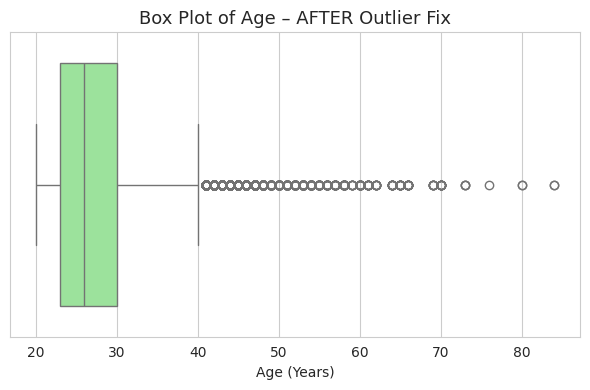

In [9]:
# Replace biologically implausible age values (>100) with NaN
df['age'] = df['age'].apply(lambda x: np.nan if pd.notna(x) and x > 100 else x)

# Impute all missing age values (original NaN + replaced outlier) with the column median
df['age'] = df['age'].fillna(df['age'].median())

# Confirm the fix by checking maximum age
print('After age fix:')
print(f'Max age: {df["age"].max()}')
print(f'Missing age values: {df["age"].isnull().sum()}')

# Box plot of age after fix
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['age'], color='lightgreen')
plt.title('Box Plot of Age – AFTER Outlier Fix', fontsize=13)
plt.xlabel('Age (Years)')
plt.tight_layout()
plt.show()

## Code Reuse Session 1 – Task: Fix Issue 2 – Missing Values in loan_interest_rate
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [10]:
# Check missing values in loan_interest_rate BEFORE fix
print('Missing loan_interest_rate BEFORE fix:', df['loan_interest_rate'].isnull().sum())

# Impute missing loan_interest_rate with the column median
df['loan_interest_rate'] = df['loan_interest_rate'].fillna(df['loan_interest_rate'].median())

# Confirm fix: no more missing values
print('Missing loan_interest_rate AFTER fix:', df['loan_interest_rate'].isnull().sum())

Missing loan_interest_rate BEFORE fix: 11
Missing loan_interest_rate AFTER fix: 0


## Code Reuse Session 1 – Task: Fix Issue 3 – Missing Values in payment_default_on_file
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [11]:
# Check missing values in payment_default_on_file BEFORE fix
print('Missing payment_default_on_file BEFORE fix:', df['payment_default_on_file'].isnull().sum())

# Impute missing values with the most frequent value (mode) for categorical variable
df['payment_default_on_file'] = df['payment_default_on_file'].fillna(
    df['payment_default_on_file'].mode()[0])

# Confirm fix
print('Missing payment_default_on_file AFTER fix:', df['payment_default_on_file'].isnull().sum())

Missing payment_default_on_file BEFORE fix: 5
Missing payment_default_on_file AFTER fix: 0


## Code Reuse Session 1 – Task: Fix Issue 4 – Negative Values in max_allowed_loan
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [12]:
# Remove rows where max_allowed_loan is negative (invalid data entry errors)
df = df[df['max_allowed_loan'] >= 0].copy()

# Confirm fix: no more negative max_allowed_loan
print('Negative max_allowed_loan AFTER fix:', (df['max_allowed_loan'] < 0).sum())
print('Dataset shape after removing invalid rows:', df.shape)

Negative max_allowed_loan AFTER fix: 0
Dataset shape after removing invalid rows: (58642, 13)


## Code Reuse Session 1 – Task: Verify All Missing Values Resolved
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [13]:
# Final check: confirm zero missing values remain in the cleaned dataset
print('Missing values AFTER ALL fixes:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values AFTER ALL fixes:
id                         0
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

Total missing values: 0


## Code Reuse Session 1 – Task: Encode Categorical Variables
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [14]:
# Encode payment_default_on_file: map N (No) -> 0, Y (Yes) -> 1
df['payment_default_on_file'] = df['payment_default_on_file'].map({'N': 0, 'Y': 1})

# Instantiate LabelEncoder for home_ownership
le_home = LabelEncoder()

# Fit and transform home_ownership to numerical labels
df['home_ownership_enc'] = le_home.fit_transform(df['home_ownership'])

# Instantiate LabelEncoder for loan_intent
le_intent = LabelEncoder()

# Fit and transform loan_intent to numerical labels
df['loan_intent_enc'] = le_intent.fit_transform(df['loan_intent'])

# Display the encoding mappings for reference
print('Home Ownership Encoding:', dict(zip(le_home.classes_, range(len(le_home.classes_)))))
print('Loan Intent Encoding:   ', dict(zip(le_intent.classes_, range(len(le_intent.classes_)))))

Home Ownership Encoding: {'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
Loan Intent Encoding:    {'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}


## Code Reuse Session 1 – Task: Create Dataset A – Classification (Loan Approval Status)
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

In [15]:
# Define the feature columns retained for classification modelling
features_classification = [
    'age', 'income', 'home_ownership_enc', 'emplyment_length',
    'loan_intent_enc', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file', 'credit_history_length'
]

# Create Dataset A for classification: retained features + target
df_classification = df[features_classification + ['loan_approval_status']].copy()

# Display the shape and confirm
print('Dataset A (Classification) shape:', df_classification.shape)
print('Features:', features_classification)
print('Target: loan_approval_status')
print('\nTarget distribution (0=Approved, 1=Rejected):')
print(df_classification['loan_approval_status'].value_counts())

# Save Dataset A to CSV for use in Notebook 2
df_classification.to_csv('dataset_A_classification.csv', index=False)
print('\nDataset A saved as dataset_A_classification.csv')

Dataset A (Classification) shape: (58642, 11)
Features: ['age', 'income', 'home_ownership_enc', 'emplyment_length', 'loan_intent_enc', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Target: loan_approval_status

Target distribution (0=Approved, 1=Rejected):
loan_approval_status
0    50292
1     8350
Name: count, dtype: int64

Dataset A saved as dataset_A_classification.csv


## Code Reuse Session 1 – Task: Create Dataset B – Regression (Maximum Loan Amount)
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

**Note:** Dataset B contains only approved clients (`loan_approval_status == 0`) with valid (`> 0`) `max_allowed_loan` values.

In [16]:
# Filter for approved clients only (loan_approval_status == 0) with positive max_allowed_loan
df_regression = df[(df['loan_approval_status'] == 0) & (df['max_allowed_loan'] > 0)].copy()

# Define the feature columns retained for regression modelling
features_regression = [
    'age', 'income', 'home_ownership_enc', 'emplyment_length',
    'loan_intent_enc', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file', 'credit_history_length'
]

# Create Dataset B for regression: retained features + target
df_regression = df_regression[features_regression + ['max_allowed_loan']].copy()

# Display the shape (dimensions) and feature names
print('Dataset B (Regression) shape:', df_regression.shape)
print('Feature names:', features_regression)
print('Target: max_allowed_loan')
print('\nMax Allowed Loan descriptive statistics:')
print(df_regression['max_allowed_loan'].describe())

# Save Dataset B to CSV for use in Notebook 3
df_regression.to_csv('dataset_B_regression.csv', index=False)
print('\nDataset B saved as dataset_B_regression.csv')

Dataset B (Regression) shape: (50292, 11)
Feature names: ['age', 'income', 'home_ownership_enc', 'emplyment_length', 'loan_intent_enc', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Target: max_allowed_loan

Max Allowed Loan descriptive statistics:
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64

Dataset B saved as dataset_B_regression.csv


## Code Reuse Session 1 – Task: Visualise Feature Distributions (Histograms)
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

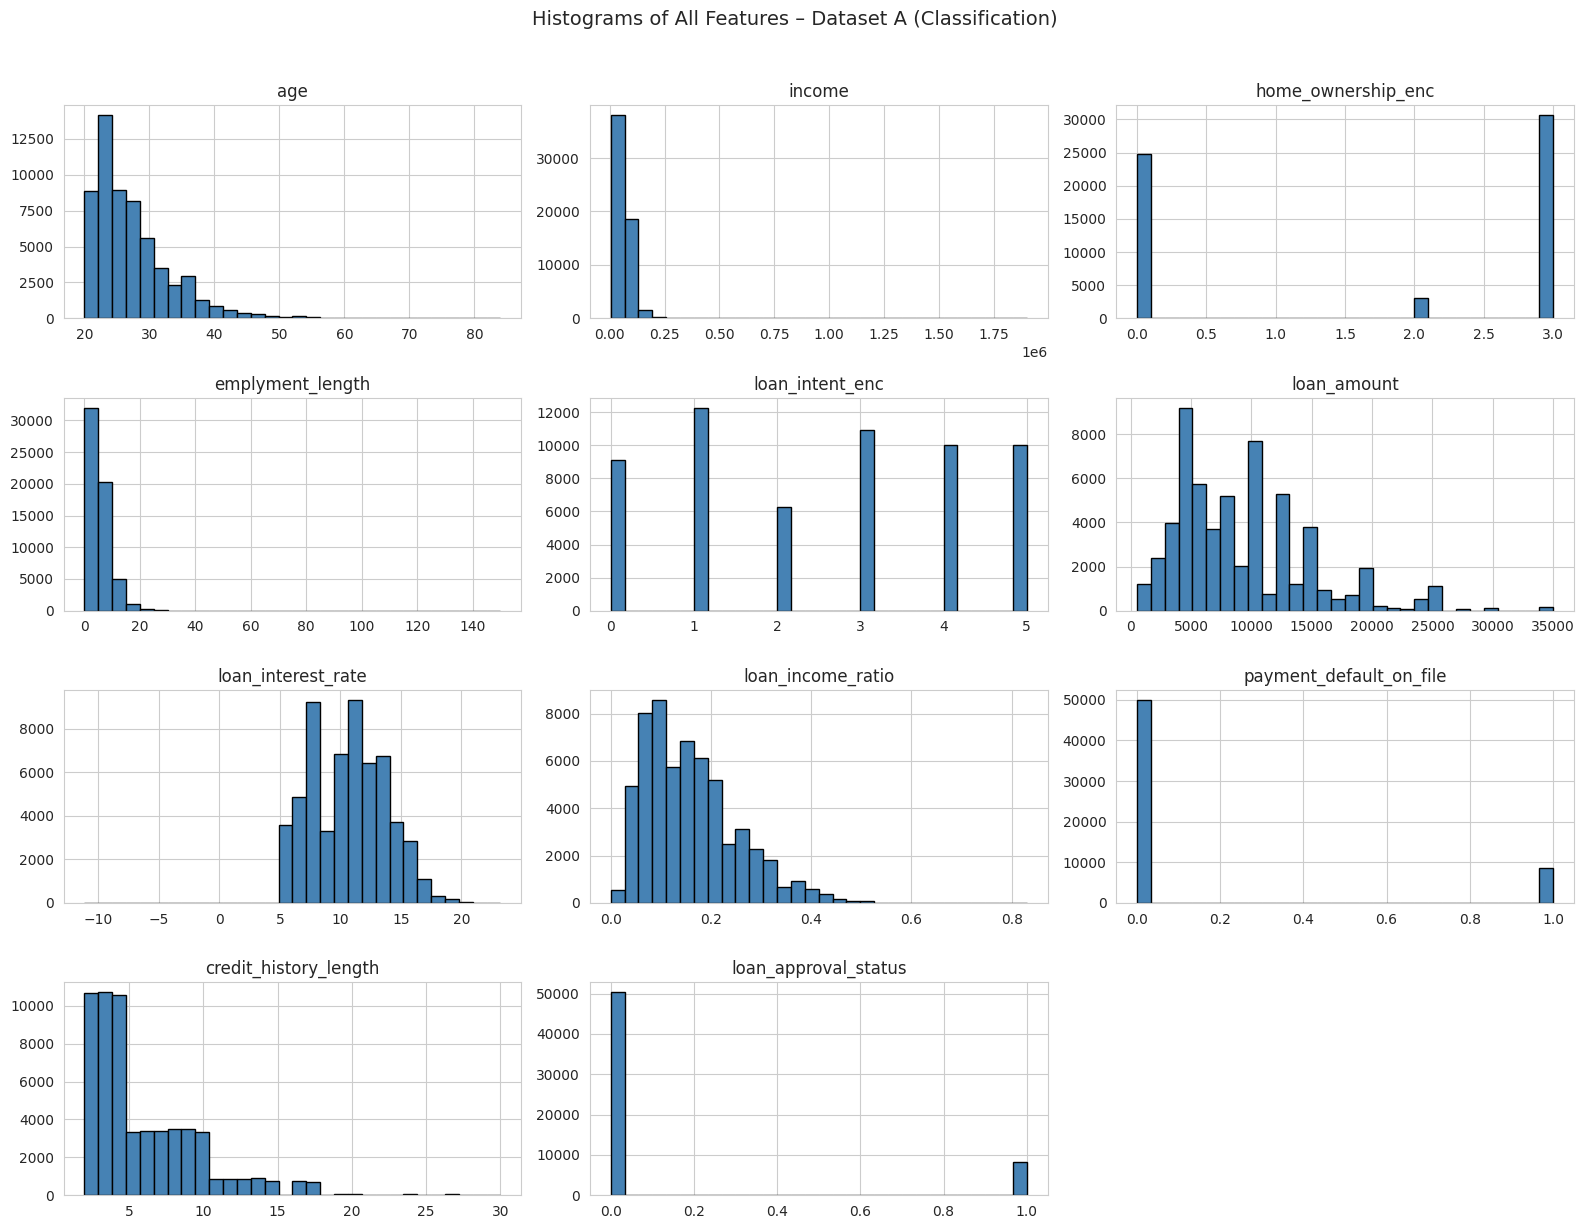

In [17]:
# Plot histograms for all numerical features in Dataset A
df_classification.hist(figsize=(16, 12), bins=30, edgecolor='black', color='steelblue')
plt.suptitle('Histograms of All Features – Dataset A (Classification)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Code Reuse Session 1 – Task: Correlation Heatmap
*(Leveraged and reused from Code Reuse Session 1, Week 3)*

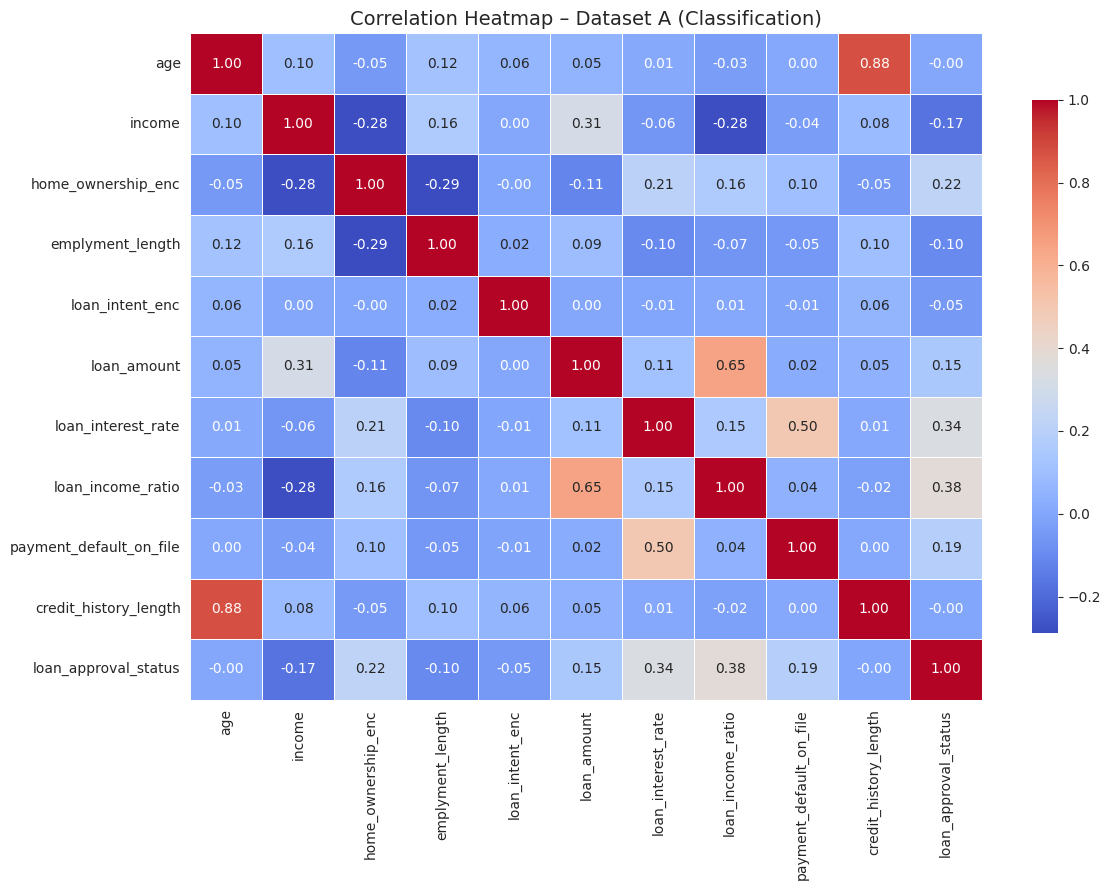

In [18]:
# Compute the Pearson correlation matrix for Dataset A
corr_matrix = df_classification.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap – Dataset A (Classification)', fontsize=14)
plt.tight_layout()
plt.show()